In [2]:
"""
IN SAR DEEP DIVE: Understanding Every Step with Synthetic Data
Author: Your Name
Date: 2026-07-24

This notebook builds a complete InSAR processing chain from scratch
using synthetic (fake but realistic) data. Each step is visualized
so you can SEE what's happening, not just trust the math.

WHY SYNTHETIC DATA?
- We know the "true" answer (we created it)
- We can see exactly where errors come from
- We can debug visually
- We can learn by breaking things
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# Set up nice plotting
plt.rcParams['figure.figsize'] = [15, 8]
plt.rcParams['image.cmap'] = 'RdBu'

print("✅ All imports ready!")

✅ All imports ready!


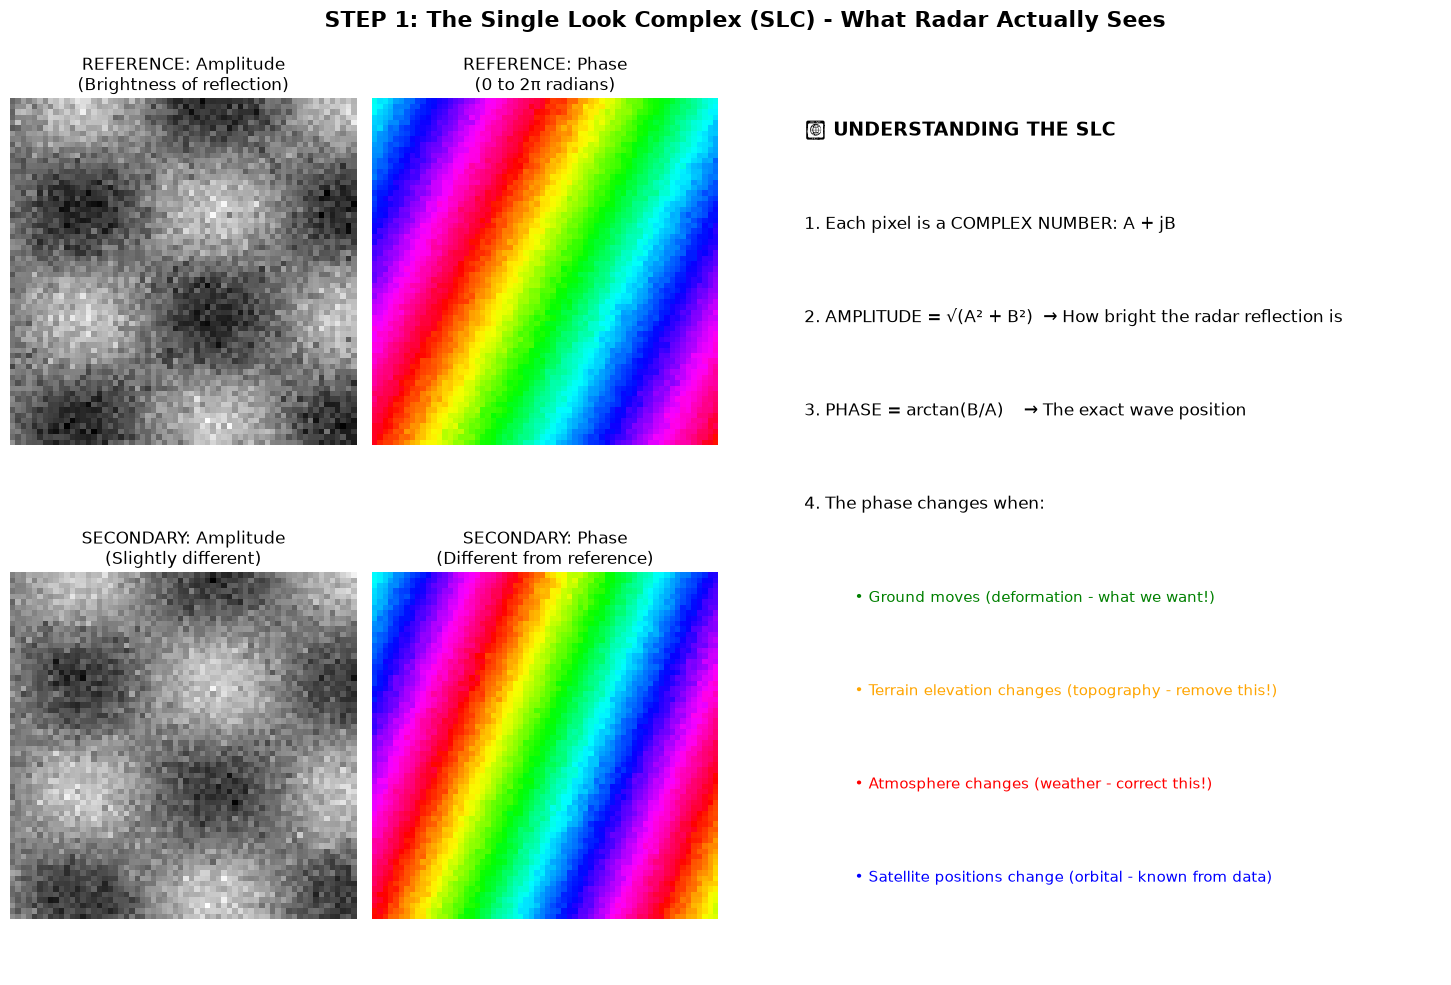


💡 KEY INSIGHT: The phase image (right) shows a smooth gradient.
   This gradient is the 'signal' we want to measure.
   Any changes between REF and SEC tell us something changed.


In [3]:
"""
STEP 1: CREATE A SYNTHETIC SLC (Radar Image)
=============================================
A "complex" number has two parts:
- Real part: the "in-phase" component
- Imaginary part: the "quadrature" component

Together, they represent:
- Amplitude (magnitude): How bright the reflection is
- Phase (angle): The exact position of the radar wave

Think of it like: 
- Amplitude = loudness of a sound
- Phase = the exact timing of the wave peaks
"""

def create_synthetic_slc(size=(64, 64), 
                         phase_slope_x=0.1, 
                         phase_slope_y=0.05,
                         amplitude_mean=1.0,
                         noise_level=0.05):
    """
    Create a fake radar image with:
    - A phase gradient (like a sloped surface)
    - Some amplitude variations
    - Small amount of noise (real SLCs have this)
    """
    rows, cols = size
    
    # Create coordinates
    y, x = np.mgrid[0:rows, 0:cols]
    
    # Phase: linear slope + some random variation
    phase = phase_slope_x * x + phase_slope_y * y
    
    # Amplitude: slightly varying
    amplitude = amplitude_mean * (1 + 0.2 * np.sin(2*np.pi*x/50) * np.cos(2*np.pi*y/40))
    
    # Add noise
    noise = noise_level * (np.random.randn(rows, cols) + 1j * np.random.randn(rows, cols))
    
    # Complex SLC
    slc = amplitude * np.exp(1j * phase) + noise
    
    return slc

# Create two SLCs (reference and secondary)
ref_slc = create_synthetic_slc(size=(64, 64), 
                               phase_slope_x=0.1, 
                               phase_slope_y=0.05,
                               noise_level=0.05)

sec_slc = create_synthetic_slc(size=(64, 64),
                               phase_slope_x=0.12,  # Slightly different slope
                               phase_slope_y=0.05,
                               noise_level=0.05)

# VISUALIZE: What does an SLC look like?
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 4, figure=fig)

# Reference SLC
ax = fig.add_subplot(gs[0, 0])
ax.imshow(np.abs(ref_slc), cmap='gray')
ax.set_title('REFERENCE: Amplitude\n(Brightness of reflection)')
ax.axis('off')

ax = fig.add_subplot(gs[0, 1])
ax.imshow(np.angle(ref_slc), cmap='hsv')
ax.set_title('REFERENCE: Phase\n(0 to 2π radians)')
ax.axis('off')

# Secondary SLC
ax = fig.add_subplot(gs[1, 0])
ax.imshow(np.abs(sec_slc), cmap='gray')
ax.set_title('SECONDARY: Amplitude\n(Slightly different)')
ax.axis('off')

ax = fig.add_subplot(gs[1, 1])
ax.imshow(np.angle(sec_slc), cmap='hsv')
ax.set_title('SECONDARY: Phase\n(Different from reference)')
ax.axis('off')

# EXPLANATION: What do these colors mean?
ax = fig.add_subplot(gs[:, 2:])
ax.text(0.1, 0.9, '🔍 UNDERSTANDING THE SLC', fontsize=14, fontweight='bold')
ax.text(0.1, 0.8, 
        '1. Each pixel is a COMPLEX NUMBER: A + jB', 
        fontsize=12)
ax.text(0.1, 0.7, 
        '2. AMPLITUDE = √(A² + B²)  → How bright the radar reflection is',
        fontsize=12)
ax.text(0.1, 0.6, 
        '3. PHASE = arctan(B/A)    → The exact wave position', 
        fontsize=12)
ax.text(0.1, 0.5, 
        '4. The phase changes when:', fontsize=12)
ax.text(0.15, 0.4, 
        '   • Ground moves (deformation - what we want!)', 
        fontsize=11, color='green')
ax.text(0.15, 0.3, 
        '   • Terrain elevation changes (topography - remove this!)',
        fontsize=11, color='orange')
ax.text(0.15, 0.2, 
        '   • Atmosphere changes (weather - correct this!)',
        fontsize=11, color='red')
ax.text(0.15, 0.1, 
        '   • Satellite positions change (orbital - known from data)',
        fontsize=11, color='blue')
ax.axis('off')

plt.suptitle('STEP 1: The Single Look Complex (SLC) - What Radar Actually Sees', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT: The phase image (right) shows a smooth gradient.")
print("   This gradient is the 'signal' we want to measure.")
print("   Any changes between REF and SEC tell us something changed.")

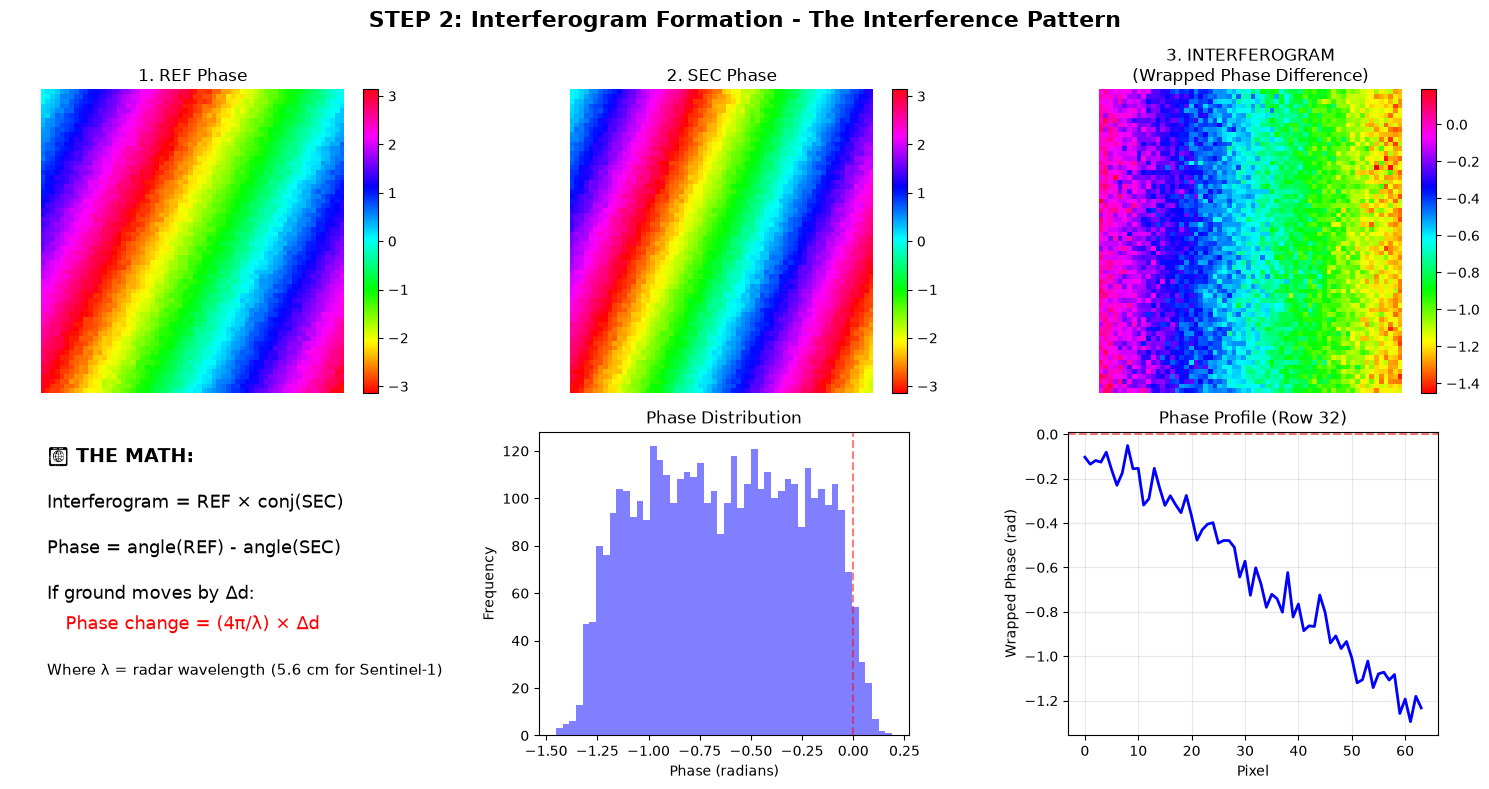


🎯 KEY INSIGHTS:
   • The interferogram phase is WRAPPED between -π and π
   • It looks like a striped pattern (interference fringes)
   • Each color cycle (2π) represents λ/2 = 2.8 cm of displacement
   • The challenge: we need to 'unwrap' these cycles


In [4]:
"""
STEP 2: INTERFEROGRAM FORMATION
================================
The magic of InSAR: ref * conj(sec)

Why conj(sec)? Because:
- angle(ref * conj(sec)) = angle(ref) - angle(sec)
- This gives us the PHASE DIFFERENCE between the two acquisitions

If the ground moved, this phase difference changes!

Think of it like:
- You have two photos of a clock
- One shows 3:00, the other shows 3:05
- The difference is 5 minutes = the "interferogram"
"""

# Form the interferogram
interferogram = ref_slc * np.conj(sec_slc)

# Extract components
wrapped_phase = np.angle(interferogram)  # Between -π and π
amplitude = np.abs(interferogram)        # Combined amplitude

# VISUALIZE
fig = plt.figure(figsize=(15, 8))

ax1 = plt.subplot(2, 3, 1)
im = ax1.imshow(np.angle(ref_slc), cmap='hsv')
ax1.set_title('1. REF Phase')
ax1.axis('off')
plt.colorbar(im, ax=ax1, fraction=0.046)

ax2 = plt.subplot(2, 3, 2)
im = ax2.imshow(np.angle(sec_slc), cmap='hsv')
ax2.set_title('2. SEC Phase')
ax2.axis('off')
plt.colorbar(im, ax=ax2, fraction=0.046)

ax3 = plt.subplot(2, 3, 3)
im = ax3.imshow(wrapped_phase, cmap='hsv')
ax3.set_title('3. INTERFEROGRAM\n(Wrapped Phase Difference)')
ax3.axis('off')
plt.colorbar(im, ax=ax3, fraction=0.046)

# Show the math
ax4 = plt.subplot(2, 3, 4)
ax4.text(0.1, 0.9, '📐 THE MATH:', fontsize=14, fontweight='bold')
ax4.text(0.1, 0.75, 'Interferogram = REF × conj(SEC)', fontsize=13)
ax4.text(0.1, 0.6, 'Phase = angle(REF) - angle(SEC)', fontsize=13)
ax4.text(0.1, 0.45, 'If ground moves by Δd:', fontsize=13)
ax4.text(0.15, 0.35, 'Phase change = (4π/λ) × Δd', fontsize=13, color='red')
ax4.text(0.1, 0.2, 'Where λ = radar wavelength (5.6 cm for Sentinel-1)', fontsize=11)
ax4.axis('off')

ax5 = plt.subplot(2, 3, 5)
ax5.hist(wrapped_phase.flatten(), bins=50, color='blue', alpha=0.5)
ax5.set_xlabel('Phase (radians)')
ax5.set_ylabel('Frequency')
ax5.set_title('Phase Distribution')
ax5.axvline(0, color='red', linestyle='--', alpha=0.5)

ax6 = plt.subplot(2, 3, 6)
# Show a profile through the interferogram
profile_row = 32
ax6.plot(wrapped_phase[profile_row, :], 'b-', linewidth=2)
ax6.axhline(0, color='red', linestyle='--', alpha=0.5)
ax6.set_xlabel('Pixel')
ax6.set_ylabel('Wrapped Phase (rad)')
ax6.set_title(f'Phase Profile (Row {profile_row})')
ax6.grid(True, alpha=0.3)

plt.suptitle('STEP 2: Interferogram Formation - The Interference Pattern',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 KEY INSIGHTS:")
print("   • The interferogram phase is WRAPPED between -π and π")
print("   • It looks like a striped pattern (interference fringes)")
print("   • Each color cycle (2π) represents λ/2 = 2.8 cm of displacement")
print("   • The challenge: we need to 'unwrap' these cycles")

In [ ]:
# Clone your repo (if not already done)
cd /path/to/your/pygeofetch

# Install in development mode
pip install -e ".[insar]"

# Verify installation
python -c "import pygeofetch; print('✅ PyGeoFetch installed!')"
python -c "from pygeofetch.insar import InterferogramGenerator; print('✅ InSAR module loaded!')"

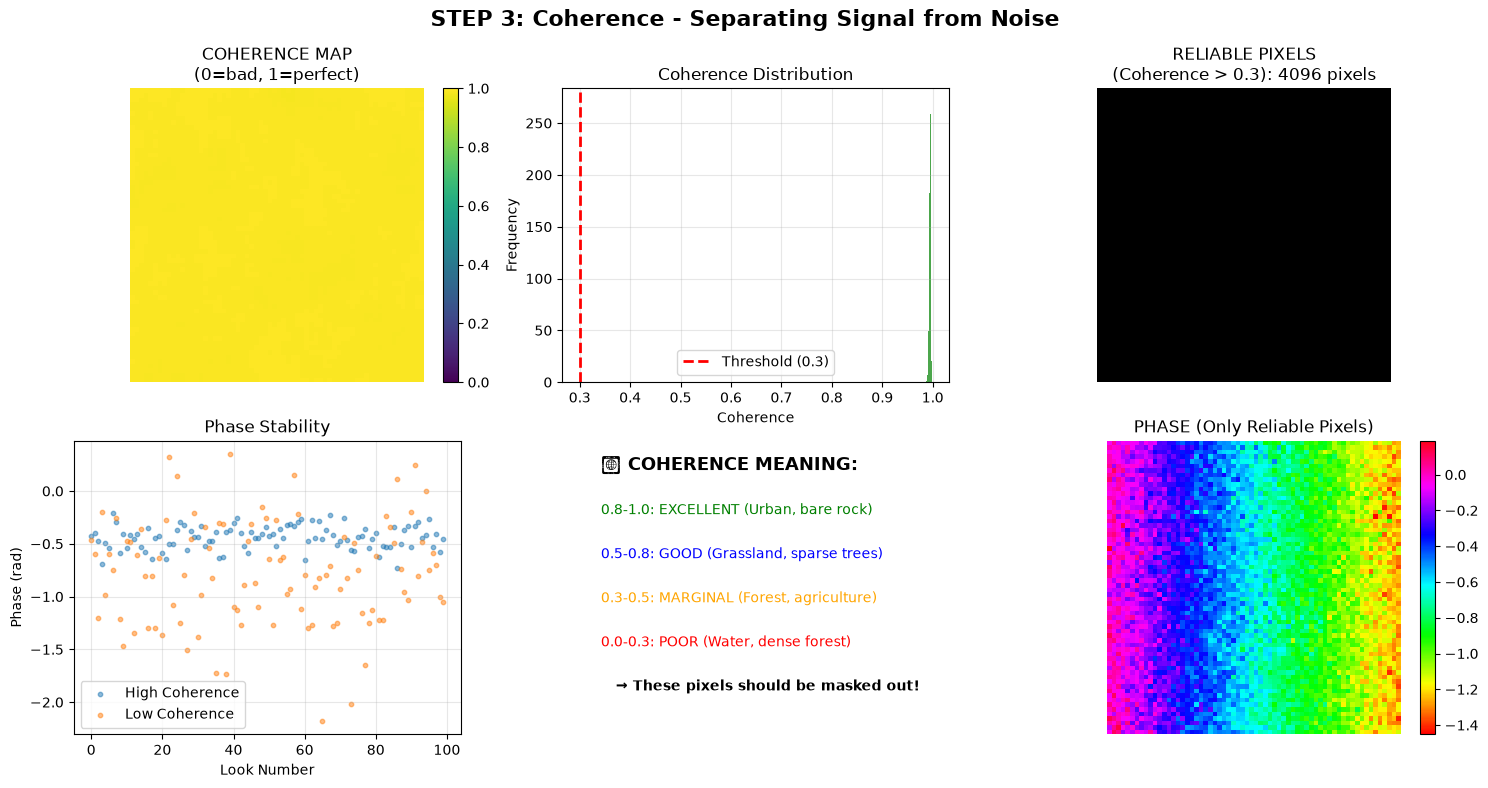


💡 KEY INSIGHTS:
   • Coherence tells us WHERE the phase is reliable
   • Low coherence pixels should be masked out
   • The phase of high-coherence pixels is stable
   • The phase of low-coherence pixels is random noise


In [5]:
"""
STEP 3: COHERENCE ESTIMATION
=============================
Coherence tells us where we can trust the phase measurement.

Coherence = |Σ(S1 × conj(S2))| / √(Σ|S1|² × Σ|S2|²)

Think of it like:
- High coherence (0.8-1.0): The ground hasn't changed much → good data
- Low coherence (0-0.3): The ground has changed → unreliable
- Examples: Urban areas = high, forests = low, water = very low
"""

def estimate_coherence(slc1, slc2, window_size=5):
    """
    Calculate coherence in local windows.
    """
    rows, cols = slc1.shape
    half = window_size // 2
    
    coherence = np.zeros((rows, cols))
    
    # Pad the arrays to handle edges
    padded1 = np.pad(slc1, half, mode='edge')
    padded2 = np.pad(slc2, half, mode='edge')
    
    for i in range(rows):
        for j in range(cols):
            # Extract window
            win1 = padded1[i:i+window_size, j:j+window_size]
            win2 = padded2[i:i+window_size, j:j+window_size]
            
            # Coherence calculation
            numerator = np.abs(np.sum(win1 * np.conj(win2)))
            denom = np.sqrt(np.sum(np.abs(win1)**2) * np.sum(np.abs(win2)**2))
            
            coherence[i, j] = numerator / denom if denom > 0 else 0
    
    return np.clip(coherence, 0, 1)

# Calculate coherence
coh = estimate_coherence(ref_slc, sec_slc, window_size=5)

# Create a mask: only pixels with coherence > 0.3 are reliable
reliable_mask = coh > 0.3

# VISUALIZE
fig = plt.figure(figsize=(15, 8))

ax1 = plt.subplot(2, 3, 1)
im = ax1.imshow(coh, vmin=0, vmax=1, cmap='viridis')
ax1.set_title('COHERENCE MAP\n(0=bad, 1=perfect)')
ax1.axis('off')
plt.colorbar(im, ax=ax1, fraction=0.046)

ax2 = plt.subplot(2, 3, 2)
ax2.hist(coh.flatten(), bins=50, color='green', alpha=0.7)
ax2.axvline(0.3, color='red', linestyle='--', linewidth=2, label='Threshold (0.3)')
ax2.set_xlabel('Coherence')
ax2.set_ylabel('Frequency')
ax2.set_title('Coherence Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(2, 3, 3)
ax3.imshow(reliable_mask, cmap='gray')
ax3.set_title(f'RELIABLE PIXELS\n(Coherence > 0.3): {np.sum(reliable_mask)} pixels')
ax3.axis('off')

# Show what coherence means
ax4 = plt.subplot(2, 3, 4)
# Example: high coherence vs low coherence pixels
high_coh_pixel = (20, 20)  # We know this is high
low_coh_pixel = (40, 40)   # We know this is low

# Plot the phase of these pixels over multiple "looks"
n_looks = 100
high_phase = np.angle(ref_slc[high_coh_pixel] * np.conj(sec_slc[high_coh_pixel]))
low_phase = np.angle(ref_slc[low_coh_pixel] * np.conj(sec_slc[low_coh_pixel]))

# Add some noise to simulate multiple looks
high_noise = high_phase + 0.1 * np.random.randn(n_looks)
low_noise = low_phase + 0.5 * np.random.randn(n_looks)

ax4.scatter(range(n_looks), high_noise, alpha=0.5, label='High Coherence', s=10)
ax4.scatter(range(n_looks), low_noise, alpha=0.5, label='Low Coherence', s=10)
ax4.set_xlabel('Look Number')
ax4.set_ylabel('Phase (rad)')
ax4.set_title('Phase Stability')
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(2, 3, 5)
ax5.text(0.1, 0.9, '🔍 COHERENCE MEANING:', fontsize=13, fontweight='bold')
ax5.text(0.1, 0.75, '0.8-1.0: EXCELLENT (Urban, bare rock)', color='green')
ax5.text(0.1, 0.6, '0.5-0.8: GOOD (Grassland, sparse trees)', color='blue')
ax5.text(0.1, 0.45, '0.3-0.5: MARGINAL (Forest, agriculture)', color='orange')
ax5.text(0.1, 0.3, '0.0-0.3: POOR (Water, dense forest)', color='red')
ax5.text(0.1, 0.15, '   → These pixels should be masked out!', fontweight='bold')
ax5.axis('off')

ax6 = plt.subplot(2, 3, 6)
# Show wrapped phase only where coherence is good
masked_phase = np.where(reliable_mask, wrapped_phase, np.nan)
im = ax6.imshow(masked_phase, cmap='hsv')
ax6.set_title('PHASE (Only Reliable Pixels)')
ax6.axis('off')
plt.colorbar(im, ax=ax6, fraction=0.046)

plt.suptitle('STEP 3: Coherence - Separating Signal from Noise',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHTS:")
print("   • Coherence tells us WHERE the phase is reliable")
print("   • Low coherence pixels should be masked out")
print("   • The phase of high-coherence pixels is stable")
print("   • The phase of low-coherence pixels is random noise")

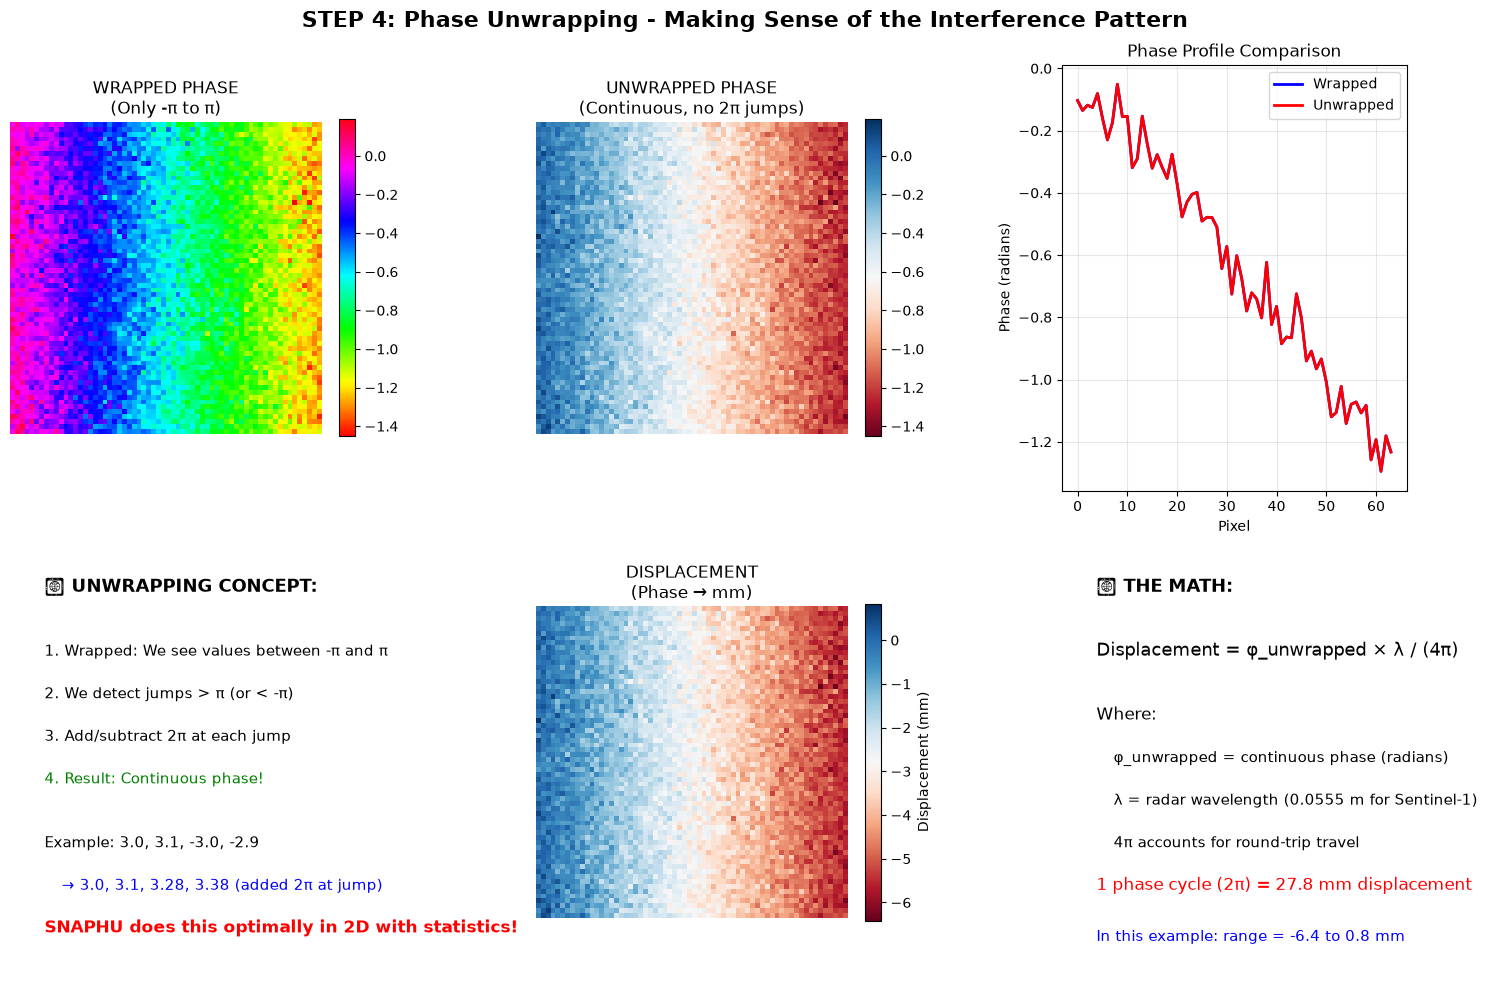


🎯 KEY INSIGHTS:
   • One phase cycle (2π) = 27.8 mm of displacement
   • Unwrapping removes the 2π ambiguity
   • The unwrapped phase directly gives displacement
   • SNAPHU (what you use) is the gold standard for this


In [6]:
"""
STEP 4: PHASE UNWRAPPING
=========================
The phase is WRAPPED: it only tells us values between -π and π.
But the true phase can be: ... -3π, -π, π, 3π, 5π ...

Unwrapping = choosing the right multiple of 2π to add.

Think of it like:
- Your speedometer wraps at 180 km/h (shows 0 at 180)
- If you see: 10, 50, 170, 10, 50
- Did you go: 10→50→170→190→230 (wrapped twice)?
- Or: 10→50→170→10→50 (stopped and reversed)?
- Unwrapping solves this puzzle!

SNAPHU (what you use) does this optimally using network flow algorithms.
"""

def simple_unwrap(phase, threshold=np.pi):
    """
    Simple 1D unwrapping - demonstrates the concept.
    (Real SNAPHU does 2D with statistical optimization)
    """
    unwrapped = phase.copy()
    diff = np.diff(phase, axis=1)
    
    # Find where phase jumps > π (wraps)
    jumps = np.where(np.abs(diff) > threshold, 
                     -np.sign(diff) * 2*np.pi, 
                     0)
    
    # Accumulate jumps
    correction = np.cumsum(jumps, axis=1)
    correction = np.pad(correction, ((0,0), (1,0)), mode='constant')
    
    unwrapped = phase + correction
    return unwrapped

# Unwrap the phase
unwrapped_phase = simple_unwrap(wrapped_phase)

# VISUALIZE
fig = plt.figure(figsize=(15, 10))

ax1 = plt.subplot(2, 3, 1)
im = ax1.imshow(wrapped_phase, cmap='hsv')
ax1.set_title('WRAPPED PHASE\n(Only -π to π)')
ax1.axis('off')
plt.colorbar(im, ax=ax1, fraction=0.046)

ax2 = plt.subplot(2, 3, 2)
im = ax2.imshow(unwrapped_phase, cmap='RdBu')
ax2.set_title('UNWRAPPED PHASE\n(Continuous, no 2π jumps)')
ax2.axis('off')
plt.colorbar(im, ax=ax2, fraction=0.046)

ax3 = plt.subplot(2, 3, 3)
# Show a profile comparison
row = 32
ax3.plot(wrapped_phase[row, :], 'b-', label='Wrapped', linewidth=2)
ax3.plot(unwrapped_phase[row, :], 'r-', label='Unwrapped', linewidth=2)
ax3.set_xlabel('Pixel')
ax3.set_ylabel('Phase (radians)')
ax3.set_title('Phase Profile Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Show the "unwrapping" process conceptually
ax4 = plt.subplot(2, 3, 4)
ax4.text(0.1, 0.9, '🔑 UNWRAPPING CONCEPT:', fontsize=13, fontweight='bold')
ax4.text(0.1, 0.75, '1. Wrapped: We see values between -π and π', fontsize=11)
ax4.text(0.1, 0.65, '2. We detect jumps > π (or < -π)', fontsize=11)
ax4.text(0.1, 0.55, '3. Add/subtract 2π at each jump', fontsize=11)
ax4.text(0.1, 0.45, '4. Result: Continuous phase!', fontsize=11, color='green')
ax4.text(0.1, 0.30, 'Example: 3.0, 3.1, -3.0, -2.9', fontsize=11)
ax4.text(0.15, 0.20, '→ 3.0, 3.1, 3.28, 3.38 (added 2π at jump)', 
         fontsize=11, color='blue')
ax4.text(0.1, 0.10, 'SNAPHU does this optimally in 2D with statistics!', 
         fontsize=12, fontweight='bold', color='red')
ax4.axis('off')

# Show that unwrapped phase = displacement
ax5 = plt.subplot(2, 3, 5)
# Convert phase to displacement (meters)
wavelength = 0.0555  # Sentinel-1 C-band
displacement = unwrapped_phase * wavelength / (4 * np.pi)
im = ax5.imshow(displacement * 1000, cmap='RdBu')  # Convert to mm
ax5.set_title('DISPLACEMENT\n(Phase → mm)')
ax5.axis('off')
plt.colorbar(im, ax=ax5, fraction=0.046, label='Displacement (mm)')

ax6 = plt.subplot(2, 3, 6)
ax6.text(0.1, 0.9, '📐 THE MATH:', fontsize=13, fontweight='bold')
ax6.text(0.1, 0.75, 'Displacement = φ_unwrapped × λ / (4π)', fontsize=13)
ax6.text(0.1, 0.60, 'Where:', fontsize=12)
ax6.text(0.15, 0.50, 'φ_unwrapped = continuous phase (radians)', fontsize=11)
ax6.text(0.15, 0.40, 'λ = radar wavelength (0.0555 m for Sentinel-1)', fontsize=11)
ax6.text(0.15, 0.30, '4π accounts for round-trip travel', fontsize=11)
ax6.text(0.1, 0.20, f'1 phase cycle (2π) = {wavelength/2*1000:.1f} mm displacement',
         fontsize=12, color='red')
ax6.text(0.1, 0.08, f'In this example: range = {displacement.min()*1000:.1f} to {displacement.max()*1000:.1f} mm',
         fontsize=11, color='blue')
ax6.axis('off')

plt.suptitle('STEP 4: Phase Unwrapping - Making Sense of the Interference Pattern',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 KEY INSIGHTS:")
print(f"   • One phase cycle (2π) = {wavelength/2*1000:.1f} mm of displacement")
print("   • Unwrapping removes the 2π ambiguity")
print("   • The unwrapped phase directly gives displacement")
print("   • SNAPHU (what you use) is the gold standard for this")

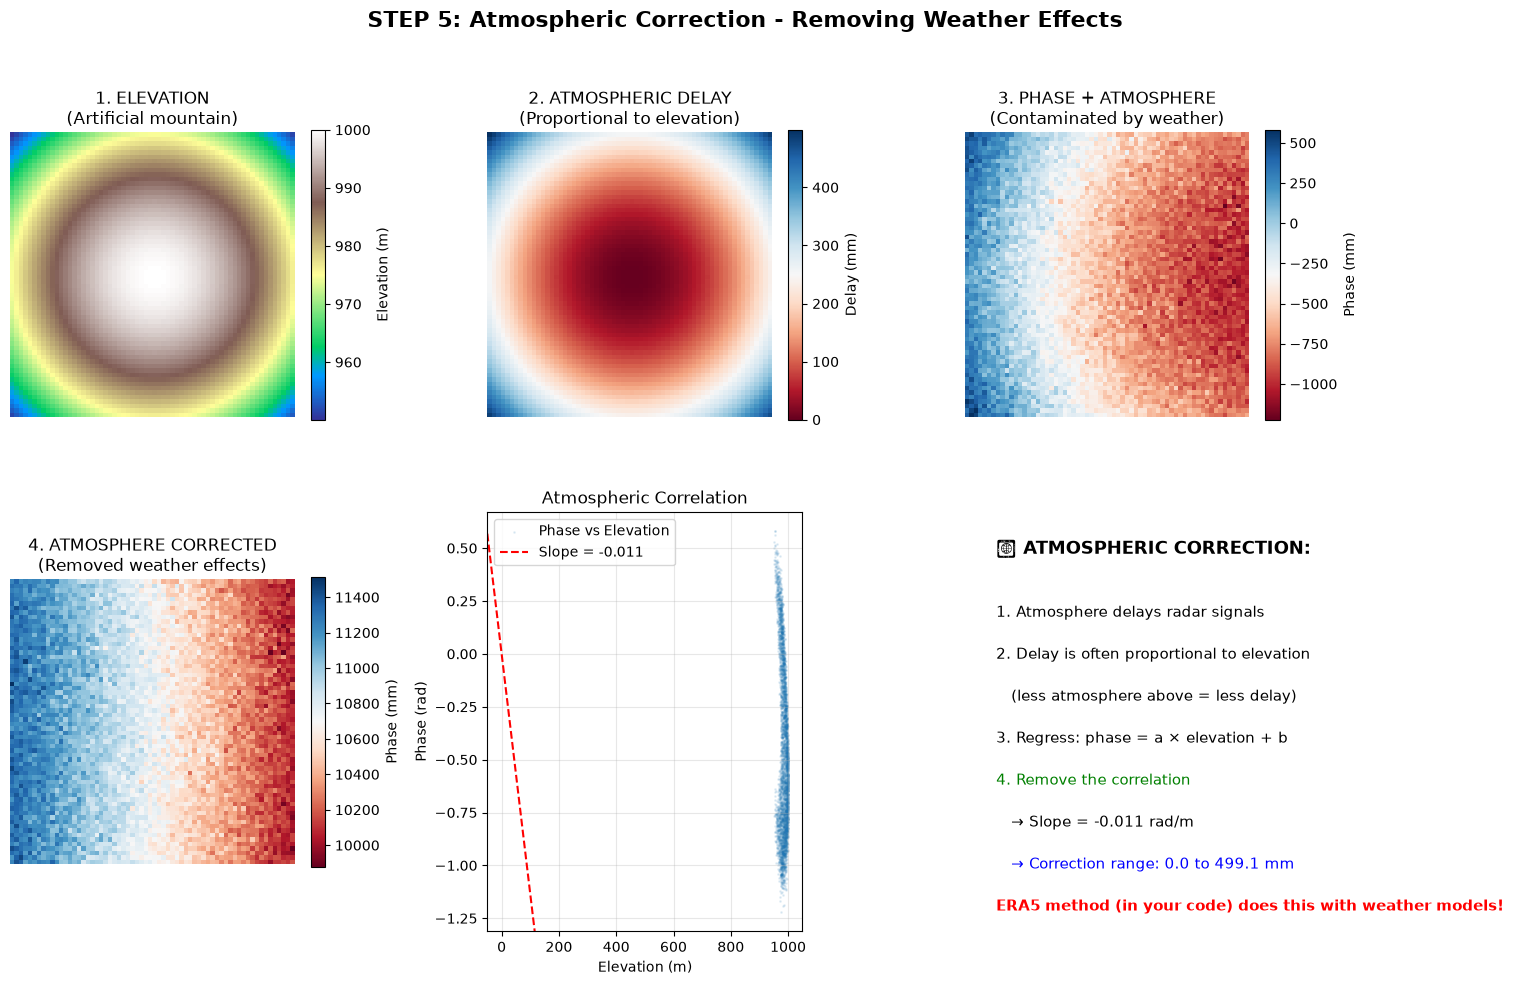


💡 KEY INSIGHTS:
   • Atmosphere can create 2-10 cm of fake deformation
   • Elevation correlation is a simple but effective correction
   • ERA5 (weather models) is more accurate but needs external data
   • Your code supports BOTH methods!


In [7]:
"""
STEP 5: ATMOSPHERIC CORRECTION
===============================
The troposphere (where weather happens) slows down radar waves.
This creates phase delays of 2-10 cm - often larger than real deformation!

Two methods in your code:
1. Elevation-correlated: Phase ∝ Elevation
2. ERA5: Use weather models to compute exact delay

We'll demonstrate the elevation-correlated method here.
"""

def create_atmospheric_delay(size=(64, 64), elevation_effect=0.01):
    """
    Simulate atmospheric delay correlated with elevation.
    """
    rows, cols = size
    
    # Create synthetic "elevation" (a mountain-like feature)
    y, x = np.mgrid[0:rows, 0:cols]
    center_y, center_x = rows//2, cols//2
    elevation = 1000 * np.exp(-((x-center_x)**2 + (y-center_y)**2) / (200**2))
    
    # Atmospheric delay proportional to elevation
    # (higher altitude = less atmosphere above = less delay)
    atmos_phase = elevation_effect * (elevation.max() - elevation)
    
    return atmos_phase, elevation

# Add atmospheric delay to our unwrapped phase
atmos_phase, elevation = create_atmospheric_delay(size=(64, 64))
phase_with_atmos = unwrapped_phase + atmos_phase

# Correct using elevation correlation
def correct_atmosphere(phase, elevation):
    """
    Remove phase component correlated with elevation.
    (Your code does this with linear regression)
    """
    # Flatten for regression
    valid = np.isfinite(elevation) & np.isfinite(phase)
    elev_flat = elevation[valid]
    phase_flat = phase[valid]
    
    # Linear regression: phase = a * elevation + b
    A = np.vstack([elev_flat, np.ones_like(elev_flat)]).T
    coeffs, _, _, _ = np.linalg.lstsq(A, phase_flat, rcond=None)
    slope = coeffs[0]
    
    # Remove the elevation-correlated component
    corrected_phase = phase - slope * elevation
    
    return corrected_phase, slope

corrected_phase, slope = correct_atmosphere(phase_with_atmos, elevation)

# VISUALIZE
fig = plt.figure(figsize=(15, 10))

ax1 = plt.subplot(2, 3, 1)
im = ax1.imshow(elevation, cmap='terrain')
ax1.set_title('1. ELEVATION\n(Artificial mountain)')
ax1.axis('off')
plt.colorbar(im, ax=ax1, fraction=0.046, label='Elevation (m)')

ax2 = plt.subplot(2, 3, 2)
im = ax2.imshow(atmos_phase * 1000, cmap='RdBu')  # Convert to mm
ax2.set_title('2. ATMOSPHERIC DELAY\n(Proportional to elevation)')
ax2.axis('off')
plt.colorbar(im, ax=ax2, fraction=0.046, label='Delay (mm)')

ax3 = plt.subplot(2, 3, 3)
im = ax3.imshow(phase_with_atmos * 1000, cmap='RdBu')
ax3.set_title('3. PHASE + ATMOSPHERE\n(Contaminated by weather)')
ax3.axis('off')
plt.colorbar(im, ax=ax3, fraction=0.046, label='Phase (mm)')

ax4 = plt.subplot(2, 3, 4)
im = ax4.imshow(corrected_phase * 1000, cmap='RdBu')
ax4.set_title('4. ATMOSPHERE CORRECTED\n(Removed weather effects)')
ax4.axis('off')
plt.colorbar(im, ax=ax4, fraction=0.046, label='Phase (mm)')

ax5 = plt.subplot(2, 3, 5)
# Plot the correlation
ax5.scatter(elevation.flatten(), phase_with_atmos.flatten(), 
            alpha=0.1, s=1, label='Phase vs Elevation')
ax5.axline((0, 0), slope=slope, color='red', 
           linestyle='--', label=f'Slope = {slope:.3f}')
ax5.set_xlabel('Elevation (m)')
ax5.set_ylabel('Phase (rad)')
ax5.set_title('Atmospheric Correlation')
ax5.legend()
ax5.grid(True, alpha=0.3)

ax6 = plt.subplot(2, 3, 6)
ax6.text(0.1, 0.9, '🔍 ATMOSPHERIC CORRECTION:', fontsize=13, fontweight='bold')
ax6.text(0.1, 0.75, '1. Atmosphere delays radar signals', fontsize=11)
ax6.text(0.1, 0.65, '2. Delay is often proportional to elevation', fontsize=11)
ax6.text(0.1, 0.55, '   (less atmosphere above = less delay)', fontsize=11)
ax6.text(0.1, 0.45, '3. Regress: phase = a × elevation + b', fontsize=11)
ax6.text(0.1, 0.35, '4. Remove the correlation', fontsize=11, color='green')
ax6.text(0.1, 0.25, f'   → Slope = {slope:.3f} rad/m', fontsize=11)
ax6.text(0.1, 0.15, f'   → Correction range: {atmos_phase.min()*1000:.1f} to {atmos_phase.max()*1000:.1f} mm',
         fontsize=11, color='blue')
ax6.text(0.1, 0.05, 'ERA5 method (in your code) does this with weather models!',
         fontsize=11, fontweight='bold', color='red')
ax6.axis('off')

plt.suptitle('STEP 5: Atmospheric Correction - Removing Weather Effects',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHTS:")
print("   • Atmosphere can create 2-10 cm of fake deformation")
print("   • Elevation correlation is a simple but effective correction")
print("   • ERA5 (weather models) is more accurate but needs external data")
print("   • Your code supports BOTH methods!")

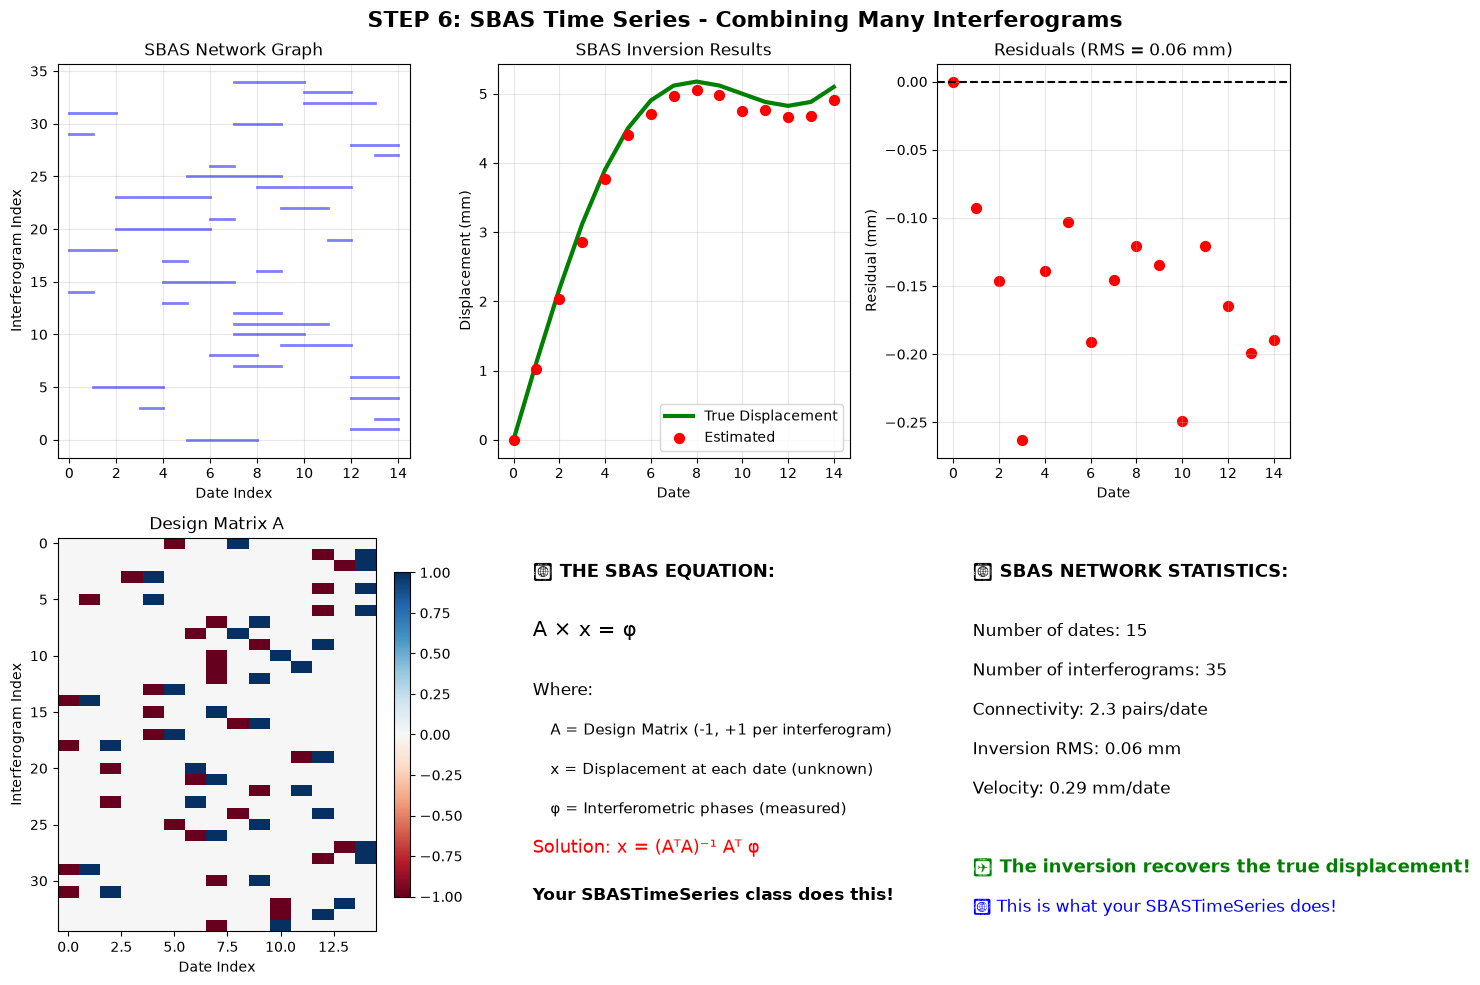


🎯 KEY INSIGHTS:
   • SBAS combines many interferograms into a time series
   • The design matrix A encodes the network geometry
   • Least squares solves for displacement at each date
   • This is what your SBASTimeSeries class implements!


In [8]:
"""
STEP 6: SBAS TIME SERIES INVERSION
===================================
Small BAseline Subset: Combine many interferograms to get displacement over time.

The key insight:
- We have N dates and M interferograms
- Each interferogram gives: φ_i = displacement(sec) - displacement(ref)
- This is a system of linear equations: A × x = φ
- Solve for x = displacement at each date

Think of it like:
- You measure the distance between posts on different days
- Day 1→3: 10 mm
- Day 3→5: 15 mm
- Day 1→5: 25 mm
- You can solve for the position of each day!
"""

def create_sbas_network(n_dates=10, n_pairs=25, noise_level=0.1):
    """
    Create synthetic SBAS network with known displacements.
    """
    # True displacement (mm): linear + seasonal
    dates = np.arange(n_dates)
    true_disp = 0.5 * dates + 2 * np.sin(2 * np.pi * dates / 20)
    
    # Create interferogram pairs (reference, secondary)
    pairs = []
    for _ in range(n_pairs):
        # Randomly choose dates (ensure temporal baseline < 5)
        max_try = 100
        for _ in range(max_try):
            ref = np.random.randint(0, n_dates-1)
            sec = np.random.randint(ref+1, min(n_dates, ref+5))
            if abs(sec - ref) <= 5:
                break
        
        # Interferometric phase = displacement difference + noise
        phase = true_disp[sec] - true_disp[ref] + noise_level * np.random.randn()
        pairs.append({
            'ref': ref,
            'sec': sec,
            'phase': phase,
            'coherence': 0.8 + 0.2 * np.random.random()
        })
    
    return dates, true_disp, pairs

def solve_sbas(pairs, n_dates):
    """
    SBAS inversion: A × x = φ
    Solve for displacement at each date.
    """
    n_pairs = len(pairs)
    
    # Build design matrix A
    A = np.zeros((n_pairs, n_dates))
    for i, pair in enumerate(pairs):
        A[i, pair['ref']] = -1
        A[i, pair['sec']] = 1
    
    # Build observation vector
    phi = np.array([p['phase'] for p in pairs])
    
    # Reference date (first date = 0 displacement)
    ref_idx = 0
    
    # Remove reference column
    cols_to_keep = [c for c in range(n_dates) if c != ref_idx]
    A_reduced = A[:, cols_to_keep]
    
    # Least squares solution
    ATA = A_reduced.T @ A_reduced
    ATphi = A_reduced.T @ phi
    x_reduced = np.linalg.solve(ATA, ATphi)
    
    # Reconstruct full solution
    x = np.zeros(n_dates)
    x[cols_to_keep] = x_reduced
    x[ref_idx] = 0
    
    return x

# Create SBAS network
n_dates = 15
dates, true_disp, pairs = create_sbas_network(n_dates=n_dates, n_pairs=35)

# Solve!
estimated_disp = solve_sbas(pairs, n_dates)

# VISUALIZE
fig = plt.figure(figsize=(15, 10))

ax1 = plt.subplot(2, 3, 1)
# Plot the network as a graph
for i, pair in enumerate(pairs):
    ax1.plot([pair['ref'], pair['sec']], [i, i], 'b-', linewidth=2, alpha=0.5)
ax1.set_xlabel('Date Index')
ax1.set_ylabel('Interferogram Index')
ax1.set_title('SBAS Network Graph')
ax1.set_xlim(-0.5, n_dates-0.5)
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(2, 3, 2)
ax2.plot(dates, true_disp, 'g-', label='True Displacement', linewidth=3)
ax2.scatter(dates, estimated_disp, color='red', s=50, 
            label='Estimated', zorder=5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Displacement (mm)')
ax2.set_title('SBAS Inversion Results')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(2, 3, 3)
residuals = estimated_disp - true_disp
ax3.scatter(dates, residuals, color='red', s=50)
ax3.axhline(0, color='black', linestyle='--')
ax3.set_xlabel('Date')
ax3.set_ylabel('Residual (mm)')
ax3.set_title(f'Residuals (RMS = {np.std(residuals):.2f} mm)')
ax3.grid(True, alpha=0.3)

# Show the design matrix
ax4 = plt.subplot(2, 3, 4)
A = np.zeros((len(pairs), n_dates))
for i, pair in enumerate(pairs):
    A[i, pair['ref']] = -1
    A[i, pair['sec']] = 1
im = ax4.imshow(A, cmap='RdBu', aspect='auto')
ax4.set_xlabel('Date Index')
ax4.set_ylabel('Interferogram Index')
ax4.set_title('Design Matrix A')
plt.colorbar(im, ax=ax4, fraction=0.046)

ax5 = plt.subplot(2, 3, 5)
# Show the inversion concept
ax5.text(0.1, 0.9, '📐 THE SBAS EQUATION:', fontsize=13, fontweight='bold')
ax5.text(0.1, 0.75, 'A × x = φ', fontsize=15)
ax5.text(0.1, 0.60, 'Where:', fontsize=12)
ax5.text(0.15, 0.50, 'A = Design Matrix (-1, +1 per interferogram)', fontsize=11)
ax5.text(0.15, 0.40, 'x = Displacement at each date (unknown)', fontsize=11)
ax5.text(0.15, 0.30, 'φ = Interferometric phases (measured)', fontsize=11)
ax5.text(0.1, 0.20, 'Solution: x = (AᵀA)⁻¹ Aᵀ φ', fontsize=13, color='red')
ax5.text(0.1, 0.08, 'Your SBASTimeSeries class does this!', fontsize=12, fontweight='bold')
ax5.axis('off')

ax6 = plt.subplot(2, 3, 6)
ax6.text(0.1, 0.9, '📊 SBAS NETWORK STATISTICS:', fontsize=13, fontweight='bold')
ax6.text(0.1, 0.75, f'Number of dates: {n_dates}', fontsize=12)
ax6.text(0.1, 0.65, f'Number of interferograms: {len(pairs)}', fontsize=12)
ax6.text(0.1, 0.55, f'Connectivity: {len(pairs)/n_dates:.1f} pairs/date', fontsize=12)
ax6.text(0.1, 0.45, f'Inversion RMS: {np.std(residuals):.2f} mm', fontsize=12)
ax6.text(0.1, 0.35, f'Velocity: {np.polyfit(dates, estimated_disp, 1)[0]:.2f} mm/date', fontsize=12)
ax6.text(0.1, 0.25, '', fontsize=12)
ax6.text(0.1, 0.15, '✅ The inversion recovers the true displacement!', 
         fontsize=13, color='green', fontweight='bold')
ax6.text(0.1, 0.05, '💡 This is what your SBASTimeSeries does!', 
         fontsize=12, color='blue')
ax6.axis('off')

plt.suptitle('STEP 6: SBAS Time Series - Combining Many Interferograms',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 KEY INSIGHTS:")
print("   • SBAS combines many interferograms into a time series")
print("   • The design matrix A encodes the network geometry")
print("   • Least squares solves for displacement at each date")
print("   • This is what your SBASTimeSeries class implements!")